# Notebook 5: MITRE ATT&CK Mapping and Semantic Contextualization

**Course Project: AI-Driven Threat Modeling for Resilient Cyber–Physical Systems**

---

## Objective

This notebook provides **explainability and semantic context** for detected threats by mapping them to established cybersecurity frameworks and knowledge bases.

**Focus:**
This notebook demonstrates explainability techniques for **STRIDE+LSTM** (our primary approach from Notebook 04), showing how AI detections can be translated into actionable operator intelligence.

**Scope:**
- Map STRIDE threats to MITRE ATT&CK for ICS tactics and techniques
- Create attack narratives linking detection → threat → technique → impact
- Build lightweight ontology representing threat relationships
- Generate human-readable explanations for operators
- Visualize semantic connections between threats

**Out of Scope:**
- New detection or learning (already done in previous notebooks)
- Real-time monitoring
- Automated response
- Framework comparison (completed in Notebook 04)

**Key Principle:**
> Explainability bridges the gap between AI detection (black box) and operator understanding (actionable knowledge).

**Note on Generalizability:**
> While this notebook focuses on STRIDE+LSTM, the mapping techniques demonstrated here (MITRE ATT&CK integration, narrative generation, ontology construction) are **framework-agnostic** and can be applied to PASTA+LSTM or other threat modeling approaches with appropriate threat-to-technique mappings.

**Architecture:**
```
┌──────────────────────────────────────────────────────────────────────────────────┐
│                     EXPLAINABILITY PIPELINE ARCHITECTURE                         │
│                          (STRIDE+LSTM Implementation)                            │
├──────────────────────────────────────────────────────────────────────────────────┤
│                                                                                  │
│  ┌──────────────────┐       ┌──────────────────┐       ┌──────────────────┐      │
│  │ LSTM DETECTION   │       │ STRIDE THREATS   │       │ MITRE ATT&CK ICS │      │
│  │   (Layer 1)      │──────▶│   (Layer 2)      │──────▶│   (Layer 3)      │──┐   │
│  │                  │       │                  │       │                  │  │   │
│  │  Attack Prob:    │       │  • Tampering     │       │  • T0836: Modify │  │   │
│  │     0.87         │       │  • Spoofing      │       │    Parameter     │  │   │
│  │  (Anomaly Score) │       │  • DoS           │       │  • T0831: Control│  │   │
│  │                  │       │                  │       │    Manipulation  │  │   │
│  └──────────────────┘       └──────────────────┘       └──────────────────┘  │   │
│         │                          │                           │             │   │
│         │                          │                           │             │   │
│      (WHAT?)                    (WHY?)                      (HOW?)           │   │
│   What detected?            Why is it a threat?       How attacker does it?  │   │
│                                                                              │   │
│                                                                              ▼   │
│                         ┌────────────────────────────────────────────────────────┤
│                         │ OPERATOR EXPLANATION (Layer 4)                         │
│                         │                                                        │
│                         │  Narrative: "PLC setpoints modified via Modbus         │
│                         │     injection, bypassing safety interlocks."           │
│                         │                                                        │
│                         │  Impact: Tank overflow, chemical contamination         │
│                         │                                                        │
│                         │  Actions:                                              │
│                         │     ✓ Enable Modbus authentication                     │
│                         │     ✓ Isolate affected PLC from network                │
│                         │     ✓ Verify safety logic integrity                    │
│                         │     ✓ Alert operator for manual verification           │
│                         │                                                        │
│                         │  (ACTION) - What operator should do?                   │
│                         └────────────────────────────────────────────────────────┘
│                                                                                  │
└──────────────────────────────────────────────────────────────────────────────────┘


🤖 AI Detection  →  🏷️ Threat Taxonomy  →  🎯 Attack Techniques  →  👤 Human Action    
```

---

## 1. Introduction to Explainability in CPS Security

### 1.1 Why Explainability Matters

**Challenge:**
- LSTM outputs attack probabilities (numerical signals)
- Security operators need actionable intelligence, not numbers
- Effective response requires understanding:
  - What threat is occurring?
  - Which system components are affected?
  - What attacker techniques are being used?
  - What are potential consequences?
  - What mitigations are appropriate?

**Solution:**
Map AI detections to established security frameworks that operators understand.

### 1.2 MITRE ATT&CK for ICS

**MITRE ATT&CK (Adversarial Tactics, Techniques, and Common Knowledge):**
- Globally accessible knowledge base of adversary behavior
- **ICS-specific matrix** covering industrial control systems
- Organized by **Tactics** (attacker goals) and **Techniques** (methods)

**11 ICS Tactics:**
1. Initial Access
2. Execution
3. Persistence
4. Privilege Escalation
5. Evasion
6. Discovery
7. Lateral Movement
8. Collection
9. Command and Control
10. Inhibit Response Function
11. Impair Process Control

### 1.3 Mapping Strategy

```
┌──────────────────────────────────────────────────────────┐
│              EXPLAINABILITY FRAMEWORK                    │
├──────────────────────────────────────────────────────────┤
│                                                          │
│  LSTM Detection                                          │
│      ↓                                                   │
│  STRIDE Threat (e.g., "Tampering with PLC Logic")        │
│      ↓                                                   │
│  MITRE ATT&CK Technique (e.g., T0836: Modify Parameter)  │
│      ↓                                                   │
│  Attack Narrative: "Attacker modified PLC setpoints      │
│   via Modbus injection, bypassing safety interlocks"     │
│      ↓                                                   │
│  Mitigation: "Enable Modbus authentication, monitor      │
│   for anomalous PLC writes, verify safety logic"         │
│                                                          │
└──────────────────────────────────────────────────────────┘
```

---

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json
import os
from collections import defaultdict

import warnings
warnings.filterwarnings('ignore')

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")

Libraries imported successfully


---

## 2. Load Previous Results

### 2.1 Load Threat Model and Detection Results

In [2]:
# Load data from previous notebooks

data_dir = 'pre_processed_data'
stride_dir = 'project_v0'

# STRIDE threats
df_stride = pd.read_csv(f'{stride_dir}/stride_threats.csv')
print(f"✓ Loaded {len(df_stride)} STRIDE threats")

# Risk baseline
df_risk = pd.read_csv(f'{stride_dir}/risk_baseline.csv')

# Add Severity column based on Risk_Score
def calculate_severity(risk_score):
    if risk_score >= 0.7:
        return 'Critical'
    elif risk_score >= 0.5:
        return 'High'
    elif risk_score >= 0.3:
        return 'Medium'
    else:
        return 'Low'

df_risk['Severity'] = df_risk['Risk_Score'].apply(calculate_severity)

# Add Impact column (use Impact (Base) if exists, otherwise derive from severity)
if 'Impact (Base)' in df_risk.columns:
    # Map impact values to descriptive text
    impact_map = {
        0.9: 'System failure, safety hazard',
        0.8: 'Process disruption, equipment damage',
        0.7: 'Service degradation, data corruption',
        0.6: 'Performance impact, minor damage',
        0.5: 'Limited operational impact',
        0.4: 'Minimal impact, easily recoverable',
        0.3: 'Negligible impact'
    }
    # Find closest match for each impact value
    df_risk['Impact'] = df_risk['Impact (Base)'].apply(
        lambda x: impact_map.get(x, f'Process impact (level {x:.1f})')
    )
else:
    # Default impact based on severity
    severity_impact_map = {
        'Critical': 'System failure, safety hazard',
        'High': 'Process disruption, equipment damage',
        'Medium': 'Service degradation, data corruption',
        'Low': 'Minimal impact, easily recoverable'
    }
    df_risk['Impact'] = df_risk['Severity'].map(severity_impact_map)

print(f"✓ Loaded risk assessments with derived severity and impact")

# LSTM predictions
y_test = np.load(f'{data_dir}/y_test_predictions.npy')
y_pred_proba = np.load(f'{data_dir}/y_pred_proba.npy')

print(f"✓ Loaded LSTM predictions ({len(y_test):,} timesteps)")

# Threat rankings
with open(f'{data_dir}/threat_rankings.json', 'r') as f:
    threat_rankings = json.load(f)

print(f"✓ Loaded threat rankings")

print(f"\nData Summary:")
print(f"  STRIDE threats: {len(df_stride)}")
print(f"  Test timesteps: {len(y_test):,}")
print(f"  Attack windows: {np.sum(y_test == 1):,}")

✓ Loaded 24 STRIDE threats
✓ Loaded risk assessments with derived severity and impact
✓ Loaded LSTM predictions (284,010 timesteps)
✓ Loaded threat rankings

Data Summary:
  STRIDE threats: 24
  Test timesteps: 284,010
  Attack windows: 16,386


---

## 3. MITRE ATT&CK for ICS Mapping

### 3.1 Define STRIDE to MITRE ATT&CK Mappings

We'll create mappings between STRIDE threats and relevant MITRE ATT&CK ICS techniques.

In [3]:
# Define MITRE ATT&CK ICS techniques mapping

mitre_techniques = {
    'T0800': {
        'name': 'Activate Firmware Update Mode',
        'tactic': 'Execution',
        'description': 'Adversaries may activate firmware update mode to upload malicious firmware.'
    },
    'T0802': {
        'name': 'Automated Collection',
        'tactic': 'Collection',
        'description': 'Adversaries may automate collection of sensitive data.'
    },
    'T0806': {
        'name': 'Brute Force I/O',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may brute force I/O signals to cause unintended effects.'
    },
    'T0807': {
        'name': 'Command-Line Interface',
        'tactic': 'Execution',
        'description': 'Adversaries may use command-line interfaces to execute commands.'
    },
    'T0809': {
        'name': 'Data Destruction',
        'tactic': 'Inhibit Response Function',
        'description': 'Adversaries may destroy data to disrupt operations.'
    },
    'T0813': {
        'name': 'Denial of Control',
        'tactic': 'Inhibit Response Function',
        'description': 'Adversaries may deny control commands to process controllers.'
    },
    'T0814': {
        'name': 'Denial of Service',
        'tactic': 'Inhibit Response Function',
        'description': 'Adversaries may perform denial of service attacks.'
    },
    'T0816': {
        'name': 'Device Restart/Shutdown',
        'tactic': 'Inhibit Response Function',
        'description': 'Adversaries may restart or shutdown devices.'
    },
    'T0826': {
        'name': 'Loss of Availability',
        'tactic': 'Impact',
        'description': 'Adversaries may cause loss of system availability.'
    },
    'T0827': {
        'name': 'Loss of Control',
        'tactic': 'Impact',
        'description': 'Adversaries may cause loss of control over physical process.'
    },
    'T0828': {
        'name': 'Loss of Productivity and Revenue',
        'tactic': 'Impact',
        'description': 'Adversaries may cause financial impact through disruption.'
    },
    'T0829': {
        'name': 'Loss of View',
        'tactic': 'Impact',
        'description': 'Adversaries may cause operators to lose visibility of process.'
    },
    'T0831': {
        'name': 'Manipulation of Control',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may manipulate control logic or commands.'
    },
    'T0832': {
        'name': 'Manipulation of View',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may manipulate operator displays to hide malicious activity.'
    },
    'T0835': {
        'name': 'Manipulate I/O Image',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may manipulate I/O image to affect process control.'
    },
    'T0836': {
        'name': 'Modify Parameter',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may modify process parameters to cause unsafe conditions.'
    },
    'T0838': {
        'name': 'Modify System Firmware',
        'tactic': 'Persistence',
        'description': 'Adversaries may modify firmware for persistence.'
    },
    'T0839': {
        'name': 'Module Firmware',
        'tactic': 'Persistence',
        'description': 'Adversaries may install malicious firmware on modules.'
    },
    'T0842': {
        'name': 'Network Connection Enumeration',
        'tactic': 'Discovery',
        'description': 'Adversaries may enumerate network connections to understand topology.'
    },
    'T0845': {
        'name': 'Program Upload',
        'tactic': 'Collection',
        'description': 'Adversaries may upload control logic programs for analysis.'
    },
    'T0855': {
        'name': 'Unauthorized Command Message',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may send unauthorized commands to devices.'
    },
    'T0856': {
        'name': 'Spoof Reporting Message',
        'tactic': 'Impair Process Control',
        'description': 'Adversaries may spoof reporting messages to hide malicious activity.'
    },
    'T0858': {
        'name': 'Change Operating Mode',
        'tactic': 'Execution',
        'description': 'Adversaries may change device operating modes.'
    },
    'T0868': {
        'name': 'Detect Operating Mode',
        'tactic': 'Discovery',
        'description': 'Adversaries may detect current operating mode of devices.'
    },
    'T0872': {
        'name': 'Indicator Removal on Host',
        'tactic': 'Evasion',
        'description': 'Adversaries may remove indicators of compromise.'
    },
    'T0883': {
        'name': 'Internet Accessible Device',
        'tactic': 'Initial Access',
        'description': 'Adversaries may leverage internet-accessible devices for access.'
    }
}

print(f"Defined {len(mitre_techniques)} MITRE ATT&CK ICS techniques")
print(f"\nExample techniques:")
for tid, info in list(mitre_techniques.items())[:5]:
    print(f"  {tid}: {info['name']} ({info['tactic']})")

Defined 26 MITRE ATT&CK ICS techniques

Example techniques:
  T0800: Activate Firmware Update Mode (Execution)
  T0802: Automated Collection (Collection)
  T0806: Brute Force I/O (Impair Process Control)
  T0807: Command-Line Interface (Execution)
  T0809: Data Destruction (Inhibit Response Function)


In [4]:
# Map STRIDE threats to MITRE ATT&CK techniques

stride_to_mitre = {
    'T1': ['T0836', 'T0831', 'T0838'],  # PLC tampering → Modify Parameter, Manipulation of Control, Modify Firmware
    'T2': ['T0856', 'T0835', 'T0832'],  # Spoofed sensors → Spoof Reporting, Manipulate I/O, Manipulation of View
    'T3': ['T0883', 'T0807'],           # Credential theft → Internet Access, Command-Line
    'T4': ['T0814', 'T0813', 'T0826'],  # DoS → Denial of Service, Denial of Control, Loss of Availability
    'T5': ['T0807', 'T0838'],           # Elevation → Command-Line, Modify Firmware
    'T6': ['T0809', 'T0872'],           # Tampering data → Data Destruction, Indicator Removal
    'T7': ['T0814', 'T0816'],           # Physical damage → DoS, Device Restart
    'T8': ['T0802', 'T0845']            # Info disclosure → Automated Collection, Program Upload
}

# Create detailed mapping dataframe
mapping_data = []

for threat_id, mitre_ids in stride_to_mitre.items():
    threat_info = df_risk[df_risk['Threat ID'] == threat_id]
    
    if len(threat_info) > 0:
        threat_info = threat_info.iloc[0]
        
        for mitre_id in mitre_ids:
            if mitre_id in mitre_techniques:
                mapping_data.append({
                    'Threat_ID': threat_id,
                    'STRIDE_Category': threat_info['STRIDE'],
                    'Threat_Description': threat_info['Threat'],
                    'Component': threat_info['Component'],
                    'MITRE_ID': mitre_id,
                    'MITRE_Technique': mitre_techniques[mitre_id]['name'],
                    'MITRE_Tactic': mitre_techniques[mitre_id]['tactic'],
                    'MITRE_Description': mitre_techniques[mitre_id]['description']
                })

df_mapping = pd.DataFrame(mapping_data)

print(f"\n✓ Created STRIDE → MITRE ATT&CK mapping")
print(f"  Total mappings: {len(df_mapping)}")
print(f"  Unique STRIDE threats: {df_mapping['Threat_ID'].nunique()}")
print(f"  Unique MITRE techniques: {df_mapping['MITRE_ID'].nunique()}")

print(f"\nExample Mappings:")
print(df_mapping[['Threat_ID', 'STRIDE_Category', 'MITRE_ID', 'MITRE_Technique']].head(10))


✓ Created STRIDE → MITRE ATT&CK mapping
  Total mappings: 19
  Unique STRIDE threats: 8
  Unique MITRE techniques: 16

Example Mappings:
  Threat_ID STRIDE_Category MITRE_ID             MITRE_Technique
0        T1       Tampering    T0836            Modify Parameter
1        T1       Tampering    T0831     Manipulation of Control
2        T1       Tampering    T0838      Modify System Firmware
3        T2        Spoofing    T0856     Spoof Reporting Message
4        T2        Spoofing    T0835        Manipulate I/O Image
5        T2        Spoofing    T0832        Manipulation of View
6        T3        Spoofing    T0883  Internet Accessible Device
7        T3        Spoofing    T0807      Command-Line Interface
8        T4             DoS    T0814           Denial of Service
9        T4             DoS    T0813           Denial of Control


### 3.2 MITRE ATT&CK Tactic Distribution

MITRE ATT&CK Tactic Distribution:
  Impair Process Control         : 5 technique(s)
  Inhibit Response Function      : 5 technique(s)
  Persistence                    : 2 technique(s)
  Execution                      : 2 technique(s)
  Collection                     : 2 technique(s)
  Initial Access                 : 1 technique(s)
  Impact                         : 1 technique(s)
  Evasion                        : 1 technique(s)


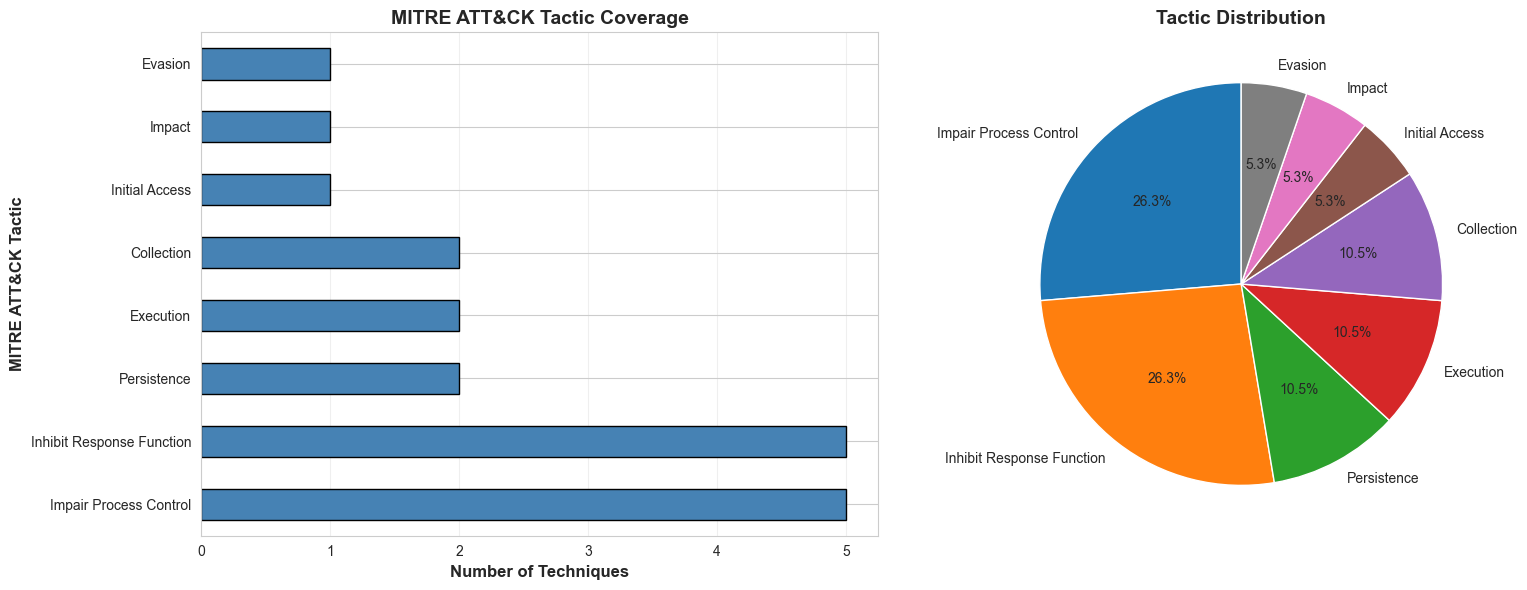


✓ MITRE tactic distribution plot saved


In [5]:
# Analyze MITRE tactic distribution

tactic_counts = df_mapping['MITRE_Tactic'].value_counts()

print("MITRE ATT&CK Tactic Distribution:")
print("=" * 60)
for tactic, count in tactic_counts.items():
    print(f"  {tactic:<30} : {count} technique(s)")

# Visualize tactic distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
tactic_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Techniques', fontweight='bold', fontsize=12)
axes[0].set_ylabel('MITRE ATT&CK Tactic', fontweight='bold', fontsize=12)
axes[0].set_title('MITRE ATT&CK Tactic Coverage', fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3, axis='x')

# Pie chart
tactic_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Tactic Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(f'{data_dir}/mitre_tactic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ MITRE tactic distribution plot saved")

---

## 4. Attack Narrative Generation

### 4.1 Create Human-Readable Explanations

When an attack is detected, we generate a narrative that explains:
1. What was detected (LSTM probability)
2. Which threats are implicated (STRIDE)
3. What attacker techniques are suspected (MITRE ATT&CK)
4. What impacts are possible
5. What mitigations are recommended

In [6]:
# Define mitigation recommendations for each STRIDE category

mitigations = {
    'Spoofing': [
        'Implement cryptographic authentication for sensor data',
        'Deploy network segmentation to isolate sensor networks',
        'Enable Modbus/DNP3 security extensions',
        'Monitor for anomalous sensor value changes'
    ],
    'Tampering': [
        'Enable code signing for PLC logic updates',
        'Implement write-protection for control parameters',
        'Deploy integrity monitoring for control logic',
        'Use secure boot and firmware verification'
    ],
    'Repudiation': [
        'Enable comprehensive audit logging',
        'Implement tamper-evident log storage',
        'Deploy SIEM for log correlation',
        'Use NTP for accurate timestamps'
    ],
    'Info Disclosure': [
        'Encrypt sensitive data at rest and in transit',
        'Implement role-based access control',
        'Deploy data loss prevention (DLP) tools',
        'Minimize data exposure through need-to-know'
    ],
    'DoS': [
        'Implement rate limiting on network protocols',
        'Deploy redundant controllers and networks',
        'Use watchdog timers and failsafe modes',
        'Monitor for resource exhaustion'
    ],
    'Elevation': [
        'Enforce least privilege access',
        'Implement multi-factor authentication',
        'Deploy privilege escalation monitoring',
        'Regular security patching and updates'
    ]
}

print("Mitigation Recommendations Defined:")
print("=" * 60)
for category, recommendations in mitigations.items():
    print(f"\n{category}:")
    for rec in recommendations[:2]:  # Show first 2
        print(f"  • {rec}")

Mitigation Recommendations Defined:

Spoofing:
  • Implement cryptographic authentication for sensor data
  • Deploy network segmentation to isolate sensor networks

Tampering:
  • Enable code signing for PLC logic updates
  • Implement write-protection for control parameters

Repudiation:
  • Enable comprehensive audit logging
  • Implement tamper-evident log storage

Info Disclosure:
  • Encrypt sensitive data at rest and in transit
  • Implement role-based access control

DoS:
  • Implement rate limiting on network protocols
  • Deploy redundant controllers and networks

Elevation:
  • Enforce least privilege access
  • Implement multi-factor authentication


In [7]:
# Generate attack narrative function

def generate_attack_narrative(threat_id, attack_probability, df_mapping, df_risk):
    """
    Generate human-readable attack narrative.
    """
    # Get threat info
    threat_info = df_risk[df_risk['Threat ID'] == threat_id].iloc[0]
    
    # Get MITRE mappings
    mitre_mappings = df_mapping[df_mapping['Threat_ID'] == threat_id]
    
    # Build narrative
    narrative = {
        'threat_id': threat_id,
        'alert_level': 'HIGH' if attack_probability > 0.7 else 'MEDIUM' if attack_probability > 0.4 else 'LOW',
        'detection': {
            'lstm_probability': float(attack_probability),
            'confidence': 'High' if attack_probability > 0.7 else 'Medium' if attack_probability > 0.4 else 'Low'
        },
        'threat': {
            'category': threat_info['STRIDE'],
            'description': threat_info['Threat'],
            'component': threat_info['Component'],
            'severity': threat_info['Severity'],
            'impact': threat_info['Impact']
        },
        'attacker_techniques': [],
        'mitigations': mitigations.get(threat_info['STRIDE'], [])
    }
    
    # Add MITRE techniques
    for _, row in mitre_mappings.iterrows():
        narrative['attacker_techniques'].append({
            'technique_id': row['MITRE_ID'],
            'technique_name': row['MITRE_Technique'],
            'tactic': row['MITRE_Tactic'],
            'description': row['MITRE_Description']
        })
    
    return narrative

# Generate narrative for top threat during attack
attack_indices = np.where(y_test == 1)[0]

if len(attack_indices) > 0:
    sample_attack_idx = attack_indices[len(attack_indices)//2]  # Middle of attack
    sample_probability = y_pred_proba[sample_attack_idx]
    
    # Get highest risk threat
    top_threat_id = df_risk.sort_values('Risk_Score', ascending=False).iloc[0]['Threat ID']
    
    narrative = generate_attack_narrative(top_threat_id, sample_probability, df_mapping, df_risk)
    
    print("\n" + "="*80)
    print("ATTACK NARRATIVE EXAMPLE")
    print("="*80)
    print(f"\n🚨 ALERT LEVEL: {narrative['alert_level']}")
    print(f"\n📊 DETECTION:")
    print(f"  LSTM Attack Probability: {narrative['detection']['lstm_probability']:.3f}")
    print(f"  Confidence: {narrative['detection']['confidence']}")
    
    print(f"\n⚠️  THREAT IDENTIFIED:")
    print(f"  ID: {narrative['threat_id']}")
    print(f"  Category: {narrative['threat']['category']}")
    print(f"  Severity: {narrative['threat']['severity']}")
    print(f"  Component: {narrative['threat']['component']}")
    print(f"  Description: {narrative['threat']['description']}")
    print(f"  Impact: {narrative['threat']['impact']}")
    
    print(f"\n🎯 SUSPECTED ATTACKER TECHNIQUES (MITRE ATT&CK):")
    for tech in narrative['attacker_techniques']:
        print(f"  • {tech['technique_id']}: {tech['technique_name']}")
        print(f"    Tactic: {tech['tactic']}")
        print(f"    {tech['description']}")
    
    print(f"\n🛡️  RECOMMENDED MITIGATIONS:")
    for i, mitigation in enumerate(narrative['mitigations'], 1):
        print(f"  {i}. {mitigation}")
    
    # Save narrative
    with open(f'{data_dir}/example_attack_narrative.json', 'w') as f:
        json.dump(narrative, f, indent=2)
    
    print(f"\n✓ Example narrative saved to {data_dir}/example_attack_narrative.json")


ATTACK NARRATIVE EXAMPLE

🚨 ALERT LEVEL: HIGH

📊 DETECTION:
  LSTM Attack Probability: 1.000
  Confidence: High

⚠️  THREAT IDENTIFIED:
  ID: T2
  Category: Spoofing
  Severity: Critical
  Component: Sensor Network
  Description: Spoofed sensor readings causing unsafe control
  Impact: System failure, safety hazard

🎯 SUSPECTED ATTACKER TECHNIQUES (MITRE ATT&CK):
  • T0856: Spoof Reporting Message
    Tactic: Impair Process Control
    Adversaries may spoof reporting messages to hide malicious activity.
  • T0835: Manipulate I/O Image
    Tactic: Impair Process Control
    Adversaries may manipulate I/O image to affect process control.
  • T0832: Manipulation of View
    Tactic: Impair Process Control
    Adversaries may manipulate operator displays to hide malicious activity.

🛡️  RECOMMENDED MITIGATIONS:
  1. Implement cryptographic authentication for sensor data
  2. Deploy network segmentation to isolate sensor networks
  3. Enable Modbus/DNP3 security extensions
  4. Monitor for 

---

## 5. Lightweight Ontology Construction

### 5.1 Define Ontology Concepts

We'll create a simple ontology representing:
- **Entities:** Threats, Components, Techniques, Impacts
- **Relations:** threatens, affects, uses, causes

In [8]:
# Build ontology as a knowledge graph

def build_threat_ontology(df_mapping, df_risk):
    """
    Build lightweight ontology representing threat relationships.
    """
    # Create directed graph
    G = nx.DiGraph()
    
    # Add nodes by type
    # 1. System components
    components = df_risk['Component'].unique()
    for comp in components:
        G.add_node(comp, node_type='Component', color='lightblue')
    
    # 2. STRIDE categories
    stride_categories = df_risk['STRIDE'].unique()
    for category in stride_categories:
        G.add_node(category, node_type='STRIDE', color='orange')
    
    # 3. MITRE techniques
    mitre_techs = df_mapping['MITRE_Technique'].unique()
    for tech in mitre_techs:
        G.add_node(tech, node_type='MITRE_Technique', color='red')
    
    # 4. Impacts
    impacts = df_risk['Impact'].unique()
    for impact in impacts:
        G.add_node(impact, node_type='Impact', color='darkred')
    
    # Add edges (relationships)
    # Component → STRIDE (threatens)
    for _, row in df_risk.iterrows():
        G.add_edge(row['Component'], row['STRIDE'], 
                  relation='threatens', weight=row['Risk_Score'])
    
    # STRIDE → Impact (causes)
    for _, row in df_risk.iterrows():
        if row['Impact'] in G.nodes():
            G.add_edge(row['STRIDE'], row['Impact'], 
                      relation='causes', weight=1.0)
    
    # STRIDE → MITRE Technique (uses)
    for _, row in df_mapping.iterrows():
        G.add_edge(row['STRIDE_Category'], row['MITRE_Technique'], 
                  relation='uses', weight=1.0)
    
    return G

# Build ontology
G = build_threat_ontology(df_mapping, df_risk)

print("Threat Ontology Constructed:")
print("=" * 60)
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"  Total edges: {G.number_of_edges()}")

print(f"\nNode Types:")
node_types = nx.get_node_attributes(G, 'node_type')
type_counts = pd.Series(node_types.values()).value_counts()
for node_type, count in type_counts.items():
    print(f"  {node_type}: {count}")

print(f"\nRelation Types:")
relations = nx.get_edge_attributes(G, 'relation')
relation_counts = pd.Series(relations.values()).value_counts()
for relation, count in relation_counts.items():
    print(f"  {relation}: {count}")

Threat Ontology Constructed:
  Total nodes: 28
  Total edges: 33

Node Types:
  MITRE_Technique: 16
  Component: 5
  STRIDE: 5
  Impact: 2

Relation Types:
  uses: 18
  threatens: 8
  causes: 7


### 5.2 Query Ontology

In [9]:
# Query ontology for insights

def query_ontology(G, query_type, entity):
    """
    Query ontology for relationships.
    """
    if entity not in G.nodes():
        return None
    
    if query_type == 'threatens_by':
        # What does this component threaten?
        return list(G.successors(entity))
    
    elif query_type == 'threatened_by':
        # What threatens this entity?
        return list(G.predecessors(entity))
    
    elif query_type == 'uses':
        # What techniques are used for this threat?
        successors = list(G.successors(entity))
        techniques = [s for s in successors if G.nodes[s].get('node_type') == 'MITRE_Technique']
        return techniques
    
    elif query_type == 'impacts':
        # What impacts does this cause?
        successors = list(G.successors(entity))
        impacts = [s for s in successors if G.nodes[s].get('node_type') == 'Impact']
        return impacts
    
    return None

# Example queries
print("\n" + "="*80)
print("ONTOLOGY QUERY EXAMPLES")
print("="*80)

# Query 1: What threatens PLC?
if 'PLC' in G.nodes():
    plc_threats = query_ontology(G, 'threatens_by', 'PLC')
    print(f"\n1. Threats targeting PLC:")
    for threat in plc_threats:
        print(f"   • {threat}")

# Query 2: What techniques are used for Tampering?
if 'Tampering' in G.nodes():
    tampering_techniques = query_ontology(G, 'uses', 'Tampering')
    print(f"\n2. Techniques used in Tampering attacks:")
    for tech in tampering_techniques[:5]:  # Show first 5
        print(f"   • {tech}")

# Query 3: What impacts does Spoofing cause?
if 'Spoofing' in G.nodes():
    spoofing_impacts = query_ontology(G, 'impacts', 'Spoofing')
    print(f"\n3. Impacts caused by Spoofing:")
    for impact in spoofing_impacts:
        print(f"   • {impact}")


ONTOLOGY QUERY EXAMPLES

1. Threats targeting PLC:
   • Tampering
   • Info Disclosure

2. Techniques used in Tampering attacks:
   • Modify Parameter
   • Manipulation of Control
   • Modify System Firmware
   • Data Destruction
   • Indicator Removal on Host

3. Impacts caused by Spoofing:
   • System failure, safety hazard


### 5.3 Visualize Ontology Subgraph

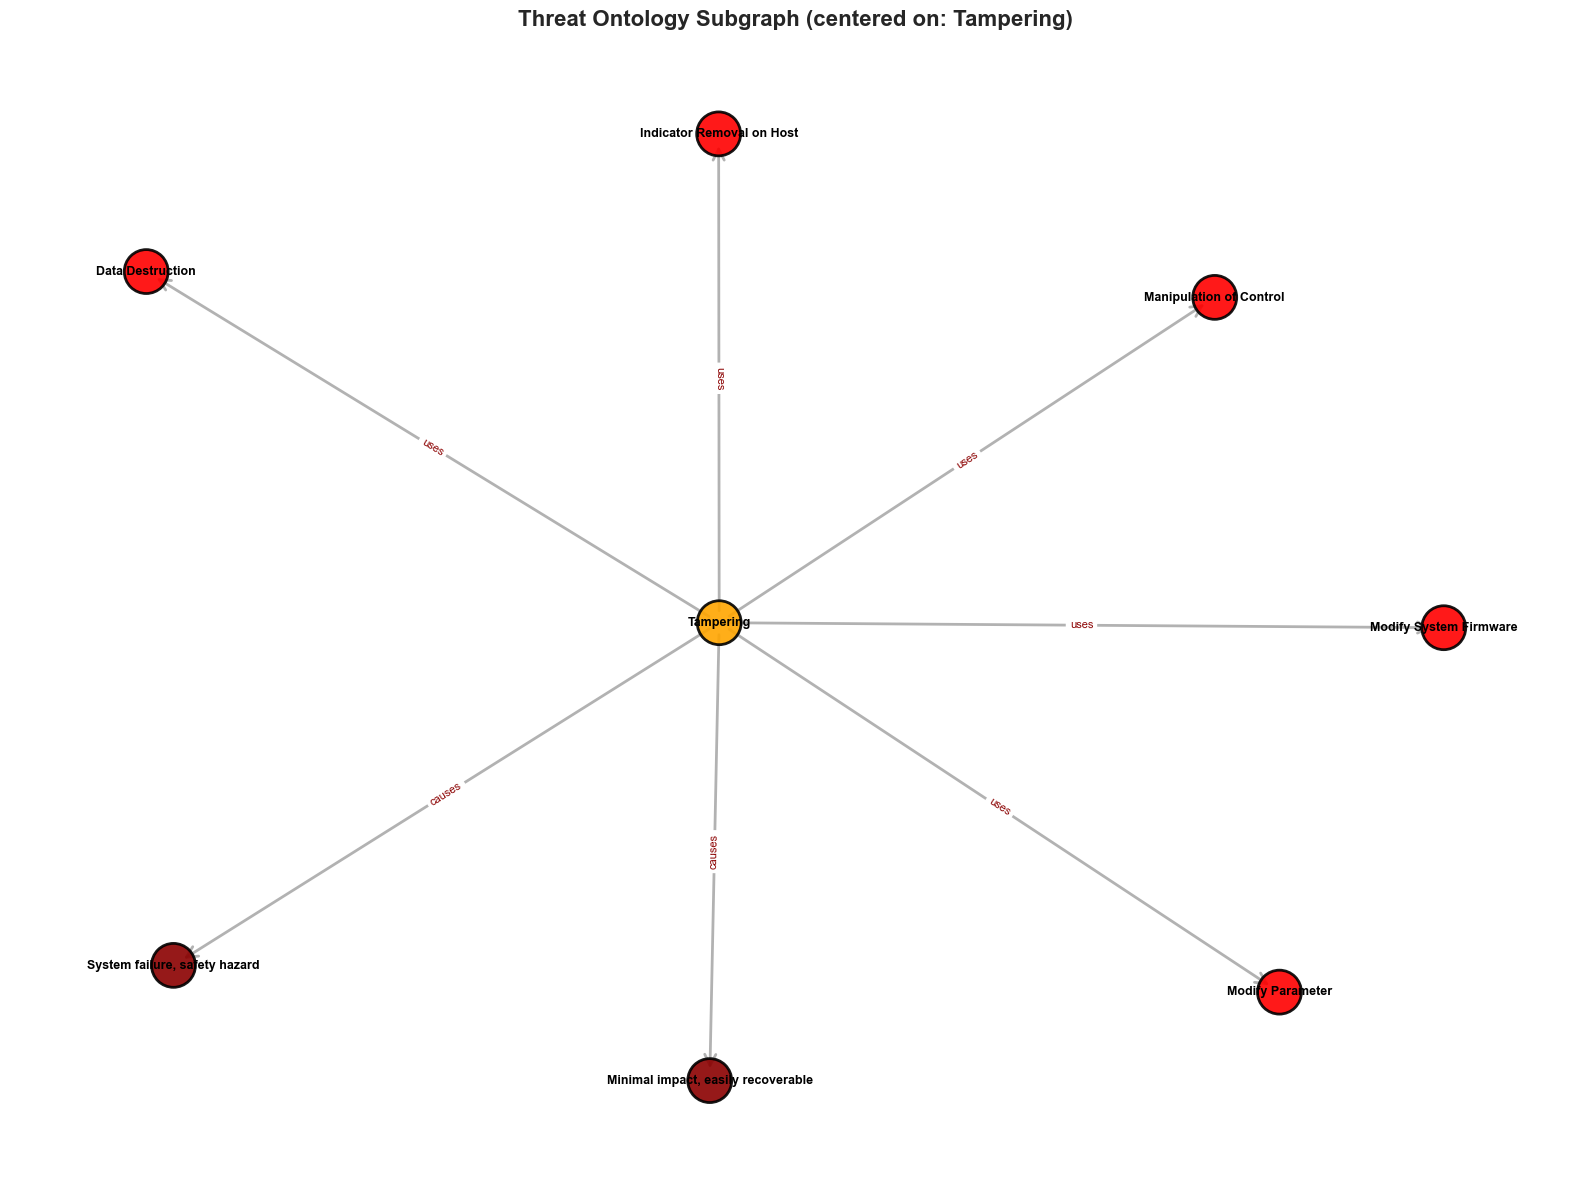

✓ Tampering subgraph saved


In [10]:
# Visualize ontology subgraph

def visualize_ontology_subgraph(G, center_node, depth=2, figsize=(16, 12)):
    """
    Visualize subgraph around a center node.
    """
    # Get ego graph (nodes within depth hops)
    if center_node not in G.nodes():
        print(f"Node '{center_node}' not found in graph")
        return
    
    ego_graph = nx.ego_graph(G, center_node, radius=depth)
    
    # Get node colors
    node_colors = [G.nodes[node].get('color', 'gray') for node in ego_graph.nodes()]
    
    # Layout
    pos = nx.spring_layout(ego_graph, k=2, iterations=50, seed=42)
    
    # Draw
    plt.figure(figsize=figsize)
    
    # Draw nodes
    nx.draw_networkx_nodes(ego_graph, pos, 
                          node_color=node_colors,
                          node_size=1000,
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=2)
    
    # Draw edges
    nx.draw_networkx_edges(ego_graph, pos,
                          edge_color='gray',
                          arrows=True,
                          arrowsize=20,
                          arrowstyle='->',
                          width=2,
                          alpha=0.6)
    
    # Draw labels
    nx.draw_networkx_labels(ego_graph, pos,
                           font_size=9,
                           font_weight='bold',
                           font_family='sans-serif')
    
    # Draw edge labels (relations)
    edge_labels = nx.get_edge_attributes(ego_graph, 'relation')
    nx.draw_networkx_edge_labels(ego_graph, pos,
                                 edge_labels=edge_labels,
                                 font_size=8,
                                 font_color='darkred')
    
    plt.title(f'Threat Ontology Subgraph (centered on: {center_node})', 
             fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    return ego_graph

# Visualize subgraph around "Tampering"
if 'Tampering' in G.nodes():
    ego = visualize_ontology_subgraph(G, 'Tampering', depth=2)
    plt.savefig(f'{data_dir}/ontology_tampering_subgraph.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Tampering subgraph saved")

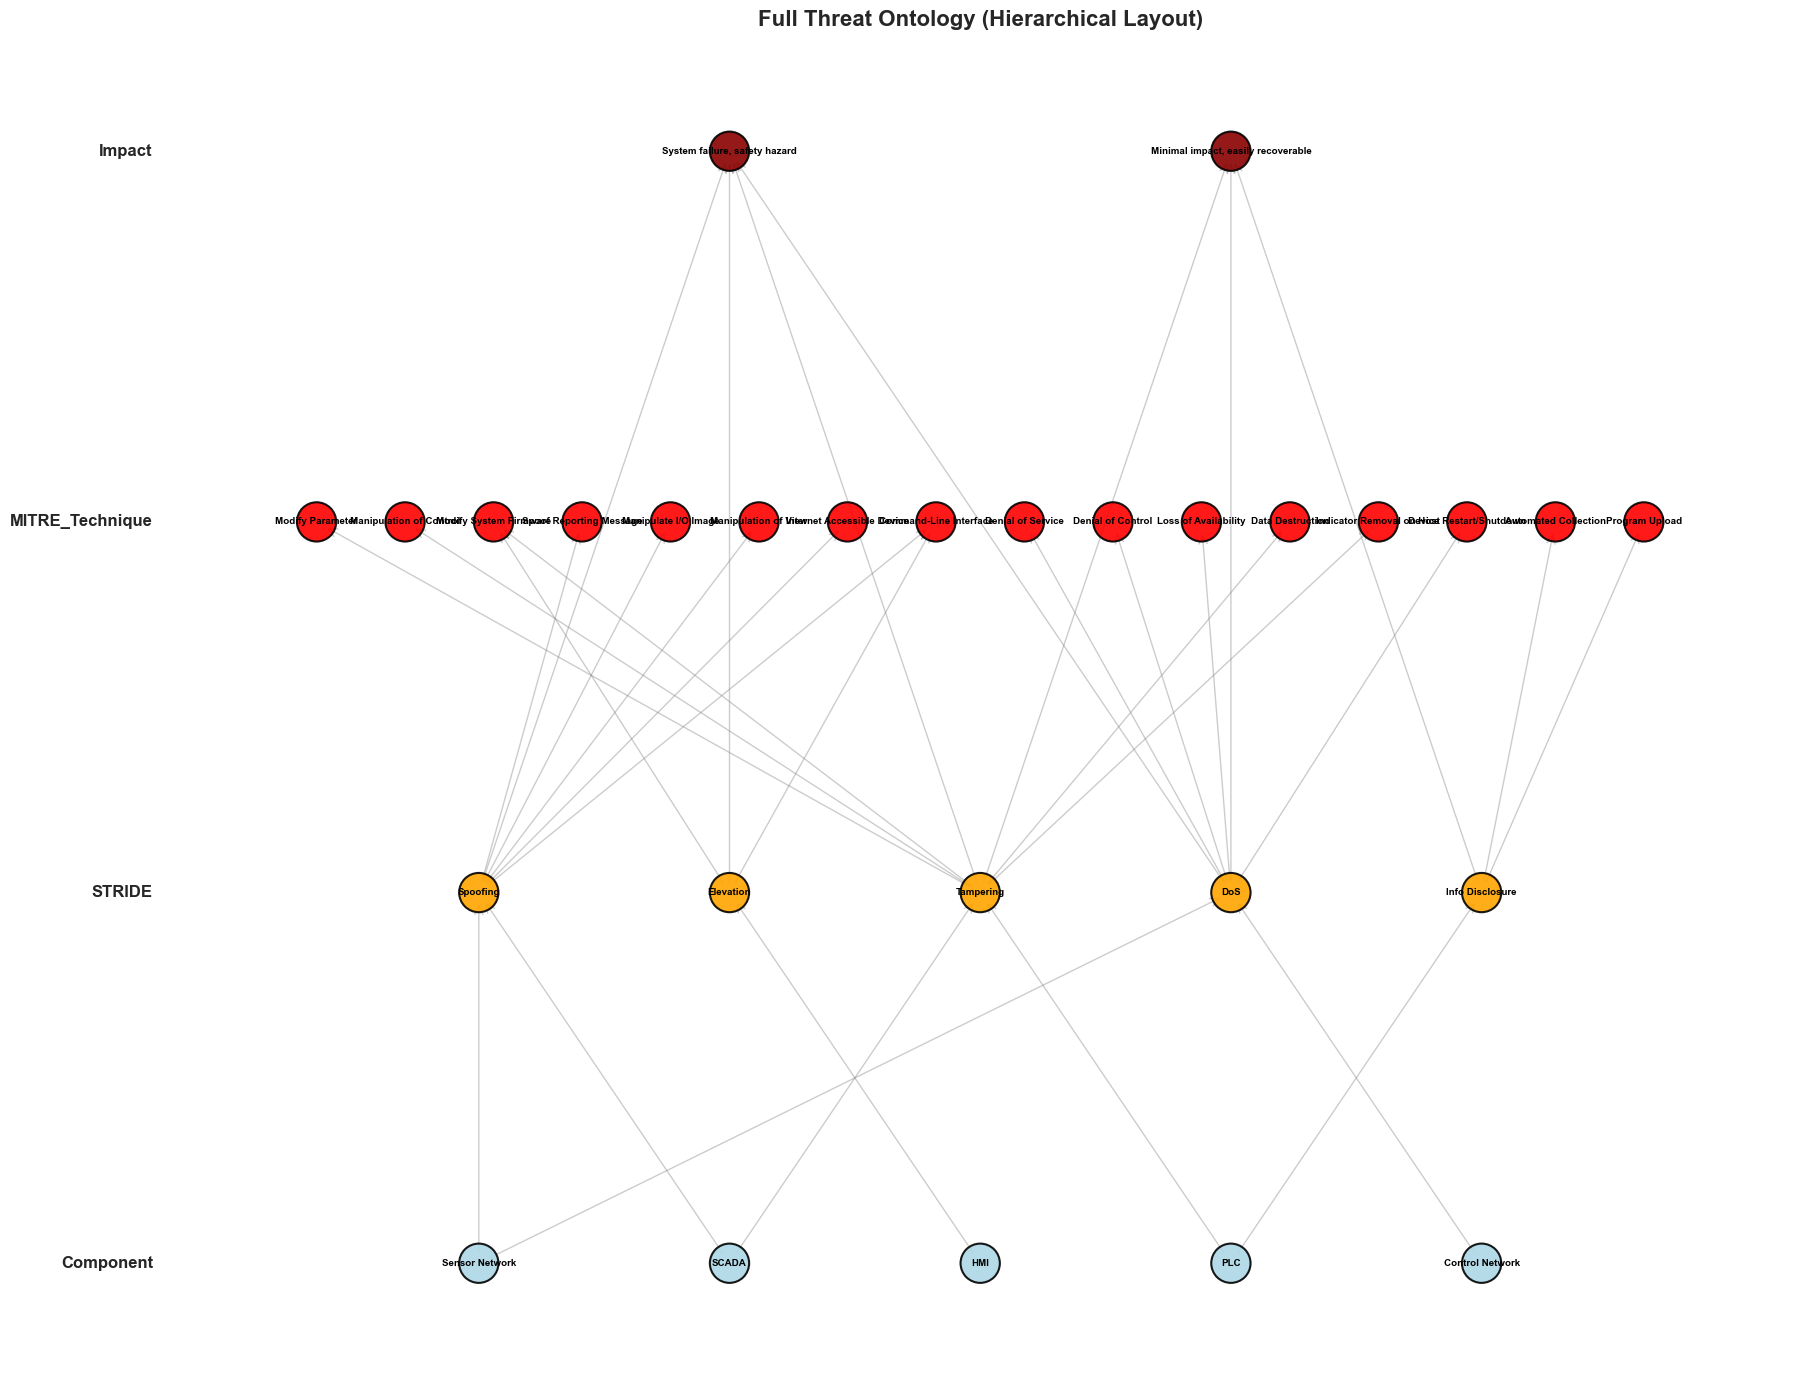

✓ Full ontology visualization saved


In [11]:
# Visualize full ontology (simplified)

def visualize_full_ontology(G, figsize=(18, 14)):
    """
    Visualize full ontology with hierarchical layout.
    """
    # Create hierarchical layout
    # Group nodes by type
    node_types = nx.get_node_attributes(G, 'node_type')
    
    pos = {}
    y_positions = {'Component': 0, 'STRIDE': 1, 'MITRE_Technique': 2, 'Impact': 3}
    
    for node_type, y in y_positions.items():
        nodes_of_type = [n for n, t in node_types.items() if t == node_type]
        x_spacing = 4.0 / (len(nodes_of_type) + 1)
        
        for i, node in enumerate(nodes_of_type):
            pos[node] = (x_spacing * (i + 1), y)
    
    # Get node colors
    node_colors = [G.nodes[node].get('color', 'gray') for node in G.nodes()]
    
    # Draw
    plt.figure(figsize=figsize)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos,
                          node_color=node_colors,
                          node_size=800,
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=1.5)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos,
                          edge_color='gray',
                          arrows=True,
                          arrowsize=15,
                          arrowstyle='->',
                          width=1,
                          alpha=0.4)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos,
                           font_size=7,
                           font_weight='bold',
                           font_family='sans-serif')
    
    plt.title('Full Threat Ontology (Hierarchical Layout)', 
             fontsize=16, fontweight='bold')
    
    # Add layer labels
    for node_type, y in y_positions.items():
        plt.text(-0.2, y, node_type, fontsize=12, fontweight='bold', 
                ha='right', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.axis('off')
    plt.tight_layout()
    
    return pos

# Visualize full ontology
pos_full = visualize_full_ontology(G)
plt.savefig(f'{data_dir}/ontology_full_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Full ontology visualization saved")

---

## 6. Semantic Relationships Analysis

### 6.1 Centrality Analysis

Identify most critical nodes in the threat ontology.


ONTOLOGY CENTRALITY ANALYSIS

Top 10 Most Central Nodes (by PageRank):
                              Node            Type  Degree_Centrality  Betweenness_Centrality  PageRank
                          Spoofing          STRIDE           0.296296                0.015670  0.062800
     System failure, safety hazard          Impact           0.148148                0.000000  0.059260
                               DoS          STRIDE           0.296296                0.016382  0.048047
            Command-Line Interface MITRE_Technique           0.074074                0.000000  0.046894
                         Elevation          STRIDE           0.148148                0.004274  0.046120
                         Tampering          STRIDE           0.333333                0.018519  0.045782
Minimal impact, easily recoverable          Impact           0.111111                0.000000  0.045187
            Modify System Firmware MITRE_Technique           0.074074                0.000000  0

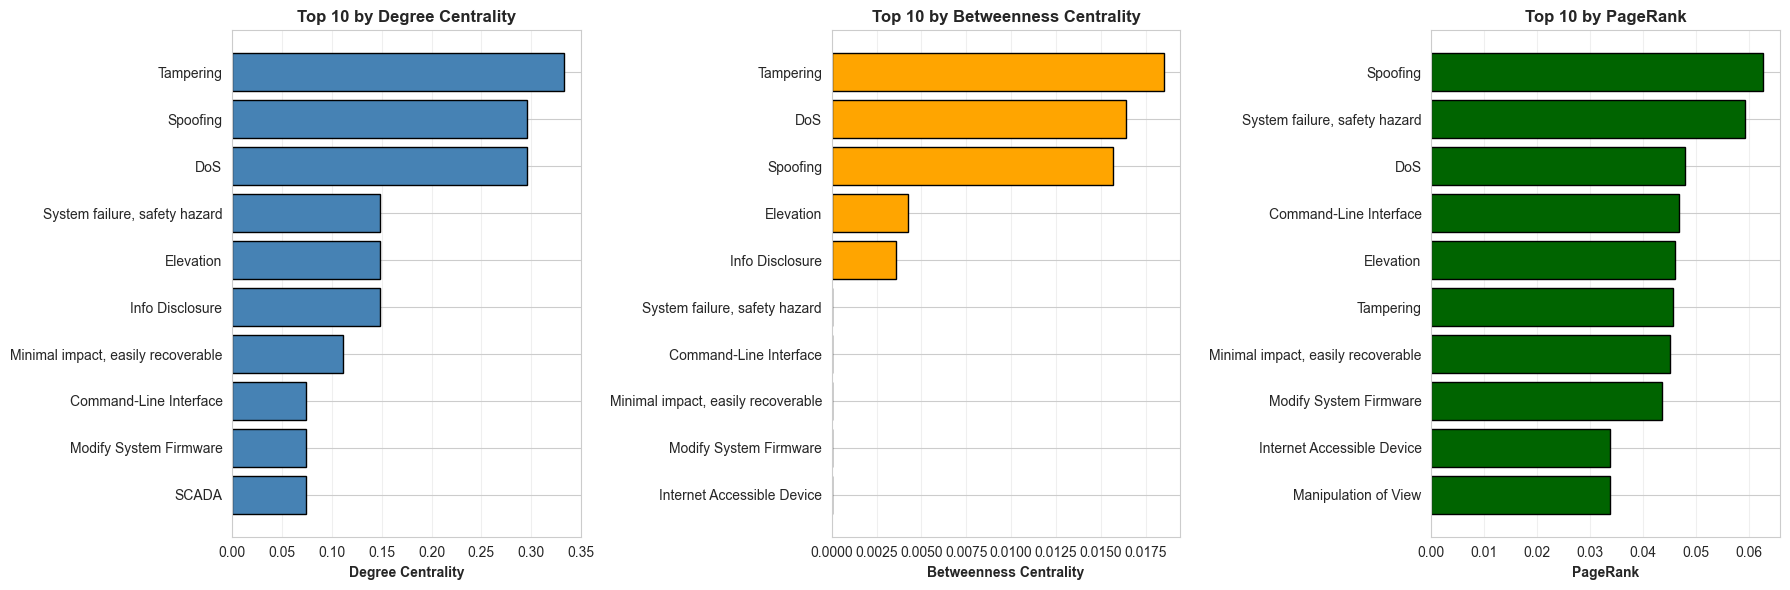


✓ Centrality analysis plot saved


In [12]:
# Compute centrality metrics

# Degree centrality (number of connections)
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality (bridging importance)
betweenness_centrality = nx.betweenness_centrality(G)

# PageRank (importance propagation)
pagerank = nx.pagerank(G)

# Create centrality dataframe
centrality_data = []
for node in G.nodes():
    centrality_data.append({
        'Node': node,
        'Type': G.nodes[node].get('node_type', 'Unknown'),
        'Degree_Centrality': degree_centrality[node],
        'Betweenness_Centrality': betweenness_centrality[node],
        'PageRank': pagerank[node]
    })

df_centrality = pd.DataFrame(centrality_data)
df_centrality = df_centrality.sort_values('PageRank', ascending=False)

print("\n" + "="*80)
print("ONTOLOGY CENTRALITY ANALYSIS")
print("="*80)

print("\nTop 10 Most Central Nodes (by PageRank):")
print(df_centrality.head(10).to_string(index=False))

# Visualize centrality
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top nodes by degree
top_degree = df_centrality.nlargest(10, 'Degree_Centrality')
axes[0].barh(top_degree['Node'], top_degree['Degree_Centrality'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Degree Centrality', fontweight='bold')
axes[0].set_title('Top 10 by Degree Centrality', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# Top nodes by betweenness
top_between = df_centrality.nlargest(10, 'Betweenness_Centrality')
axes[1].barh(top_between['Node'], top_between['Betweenness_Centrality'], color='orange', edgecolor='black')
axes[1].set_xlabel('Betweenness Centrality', fontweight='bold')
axes[1].set_title('Top 10 by Betweenness Centrality', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

# Top nodes by PageRank
top_pagerank = df_centrality.nlargest(10, 'PageRank')
axes[2].barh(top_pagerank['Node'], top_pagerank['PageRank'], color='darkgreen', edgecolor='black')
axes[2].set_xlabel('PageRank', fontweight='bold')
axes[2].set_title('Top 10 by PageRank', fontweight='bold', fontsize=12)
axes[2].invert_yaxis()
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{data_dir}/ontology_centrality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Centrality analysis plot saved")

### 6.2 Attack Path Analysis

Identify potential attack paths through the ontology.

In [13]:
# Find attack paths from components to impacts

def find_attack_paths(G, source_type='Component', target_type='Impact', max_paths=5):
    """
    Find attack paths from source nodes to target nodes.
    """
    source_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type') == source_type]
    target_nodes = [n for n in G.nodes() if G.nodes[n].get('node_type') == target_type]
    
    paths = []
    
    for source in source_nodes[:3]:  # Limit sources for performance
        for target in target_nodes[:3]:  # Limit targets for performance
            try:
                # Find all simple paths
                simple_paths = list(nx.all_simple_paths(G, source, target, cutoff=4))
                paths.extend(simple_paths[:max_paths])
            except nx.NetworkXNoPath:
                continue
    
    return paths

# Find attack paths
attack_paths = find_attack_paths(G, 'Component', 'Impact', max_paths=3)

print("\n" + "="*80)
print("ATTACK PATH ANALYSIS")
print("="*80)

print(f"\nFound {len(attack_paths)} attack paths (Component → Impact)")
print(f"\nExample Attack Paths:\n")

for i, path in enumerate(attack_paths[:10], 1):  # Show first 10
    print(f"{i}. {' → '.join(path)}")
    
    # Annotate path
    relations = []
    for j in range(len(path) - 1):
        edge_data = G.get_edge_data(path[j], path[j+1])
        if edge_data and 'relation' in edge_data:
            relations.append(edge_data['relation'])
    
    print(f"   Relations: {' → '.join(relations)}")
    print()


ATTACK PATH ANALYSIS

Found 7 attack paths (Component → Impact)

Example Attack Paths:

1. Sensor Network → Spoofing → System failure, safety hazard
   Relations: threatens → causes

2. Sensor Network → DoS → System failure, safety hazard
   Relations: threatens → causes

3. Sensor Network → DoS → Minimal impact, easily recoverable
   Relations: threatens → causes

4. SCADA → Spoofing → System failure, safety hazard
   Relations: threatens → causes

5. SCADA → Tampering → System failure, safety hazard
   Relations: threatens → causes

6. SCADA → Tampering → Minimal impact, easily recoverable
   Relations: threatens → causes

7. HMI → Elevation → System failure, safety hazard
   Relations: threatens → causes



---

## 7. Export Ontology and Mappings

### 7.1 Save Ontology Data

In [14]:
# Export ontology as various formats

# 1. Export as GraphML (standard format)
nx.write_graphml(G, f'{data_dir}/threat_ontology.graphml')
print(f"✓ Ontology saved as GraphML: {data_dir}/threat_ontology.graphml")

# 2. Export as edge list
nx.write_edgelist(G, f'{data_dir}/threat_ontology_edges.txt', data=True)
print(f"✓ Ontology edge list saved")

# 3. Export mappings as CSV
df_mapping.to_csv(f'{data_dir}/stride_mitre_mapping.csv', index=False)
print(f"✓ STRIDE-MITRE mapping saved as CSV")

# 4. Export centrality analysis
df_centrality.to_csv(f'{data_dir}/ontology_centrality.csv', index=False)
print(f"✓ Centrality analysis saved")

# 5. Create ontology summary
ontology_summary = {
    'statistics': {
        'total_nodes': G.number_of_nodes(),
        'total_edges': G.number_of_edges(),
        'node_types': dict(type_counts),
        'relation_types': dict(relation_counts)
    },
    'top_central_nodes': df_centrality.head(10).to_dict('records'),
    'mitre_techniques_covered': len(df_mapping['MITRE_ID'].unique()),
    'stride_threats_mapped': len(df_mapping['Threat_ID'].unique())
}

with open(f'{data_dir}/ontology_summary.json', 'w') as f:
    json.dump(ontology_summary, f, indent=2, default=lambda o: int(o) if isinstance(o, (np.integer,)) else float(o) if isinstance(o, (np.floating,)) else str(o))

print(f"✓ Ontology summary saved")

✓ Ontology saved as GraphML: pre_processed_data/threat_ontology.graphml
✓ Ontology edge list saved
✓ STRIDE-MITRE mapping saved as CSV
✓ Centrality analysis saved
✓ Ontology summary saved


---

## 8. Operator Dashboard Mock-Up

### 8.1 Create Summary Table for Operators

Generate a concise threat summary table suitable for operator displays.

In [15]:
# Create operator-friendly threat summary

def create_operator_summary(df_risk, df_mapping, top_n=10):
    """
    Create operator-friendly threat summary with MITRE context.
    """
    # Get top threats by risk
    top_threats = df_risk.sort_values('Risk_Score', ascending=False).head(top_n)
    
    summary_data = []
    
    for _, threat in top_threats.iterrows():
        # Get MITRE mappings
        mitre_info = df_mapping[df_mapping['Threat_ID'] == threat['Threat ID']]
        mitre_techniques = ', '.join(mitre_info['MITRE_ID'].tolist())
        
        summary_data.append({
            'Priority': len(summary_data) + 1,
            'Threat_ID': threat['Threat ID'],
            'Category': threat['STRIDE'],
            'Component': threat['Component'],
            'Severity': threat['Severity'],
            'Risk_Score': f"{threat['Risk_Score']:.3f}",
            'MITRE_Techniques': mitre_techniques if mitre_techniques else 'N/A',
            'Description': threat['Threat'][:60] + '...' if len(threat['Threat']) > 60 else threat['Threat']
        })
    
    return pd.DataFrame(summary_data)

# Create operator summary
df_operator_summary = create_operator_summary(df_risk, df_mapping, top_n=10)

print("\n" + "="*100)
print("OPERATOR THREAT DASHBOARD")
print("="*100)
print()
print(df_operator_summary.to_string(index=False))

# Save operator summary
df_operator_summary.to_csv(f'{data_dir}/operator_threat_summary.csv', index=False)
print(f"\n✓ Operator summary saved to {data_dir}/operator_threat_summary.csv")


OPERATOR THREAT DASHBOARD

 Priority Threat_ID        Category       Component Severity Risk_Score    MITRE_Techniques                                    Description
        1        T2        Spoofing  Sensor Network Critical      1.500 T0856, T0835, T0832 Spoofed sensor readings causing unsafe control
        2        T3        Spoofing           SCADA Critical      1.440        T0883, T0807            SCADA credential theft via phishing
        3        T5       Elevation             HMI Critical      1.440        T0807, T0838      Elevation of privilege on HMI workstation
        4        T1       Tampering             PLC Critical      0.900 T0836, T0831, T0838           Malicious PLC ladder logic injection
        5        T4             DoS Control Network Critical      0.800 T0814, T0813, T0826      Denial of service against control network
        6        T6       Tampering           SCADA      Low      0.200        T0809, T0872                  Tampering with historian data

### 8.2 Visualize Top Threats with MITRE Context

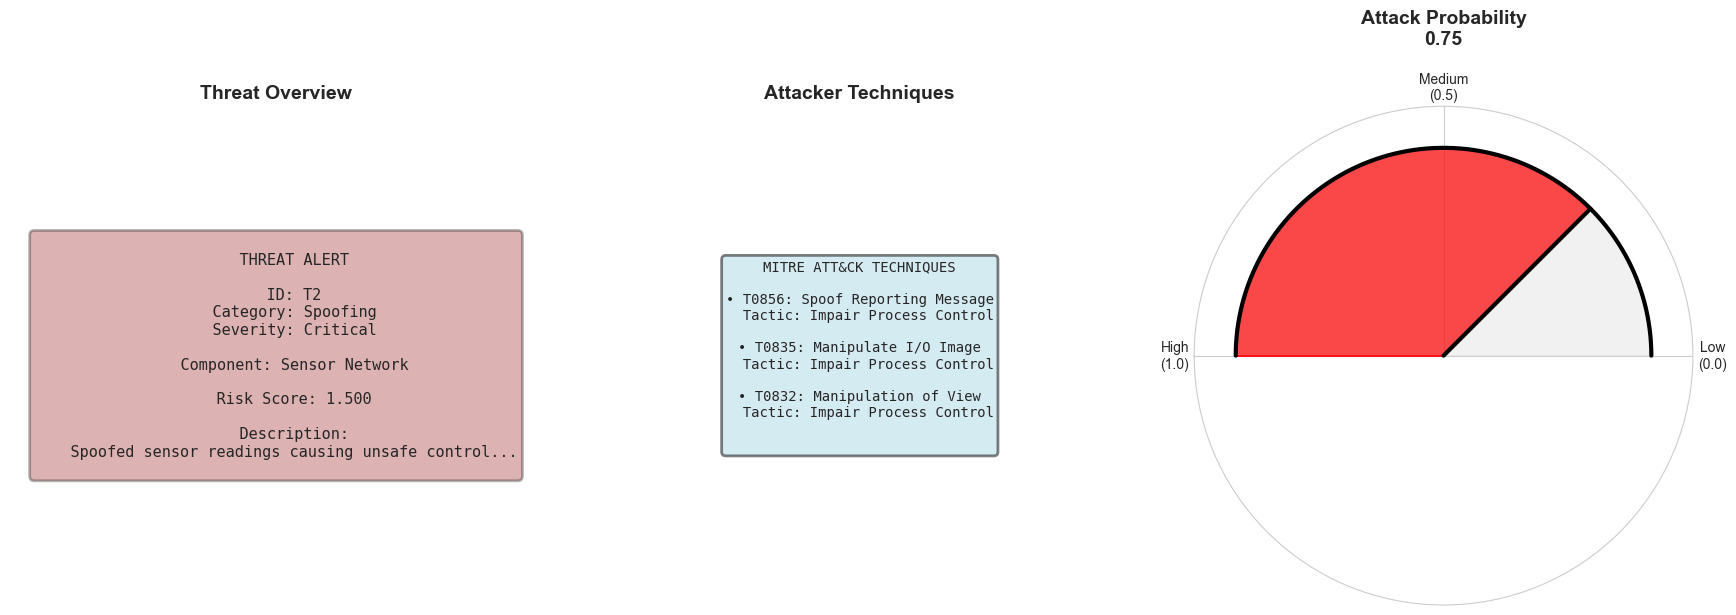

✓ Threat card visualization saved


In [16]:
# Create visual threat card

def create_threat_card(threat_info, mitre_info, attack_prob=0.5):
    """
    Create visual threat card for operator display.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Card 1: Threat Overview
    axes[0].axis('off')
    overview_text = f"""
    THREAT ALERT
    
    ID: {threat_info['Threat ID']}
    Category: {threat_info['STRIDE']}
    Severity: {threat_info['Severity']}
    
    Component: {threat_info['Component']}
    
    Risk Score: {threat_info['Risk_Score']:.3f}
    
    Description:
    {threat_info['Threat'][:150]}...
    """
    
    # Color based on severity
    color_map = {'Critical': 'darkred', 'High': 'red', 'Medium': 'orange', 'Low': 'yellow'}
    bg_color = color_map.get(threat_info['Severity'], 'gray')
    
    axes[0].text(0.5, 0.5, overview_text, 
                ha='center', va='center',
                fontsize=11, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor=bg_color, alpha=0.3, edgecolor='black', linewidth=2))
    axes[0].set_title('Threat Overview', fontweight='bold', fontsize=14)
    
    # Card 2: MITRE ATT&CK Context
    axes[1].axis('off')
    mitre_text = "MITRE ATT&CK TECHNIQUES\n\n"
    for _, row in mitre_info.iterrows():
        mitre_text += f"• {row['MITRE_ID']}: {row['MITRE_Technique']}\n"
        mitre_text += f"  Tactic: {row['MITRE_Tactic']}\n\n"
    
    axes[1].text(0.5, 0.5, mitre_text,
                ha='center', va='center',
                fontsize=10, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='black', linewidth=2))
    axes[1].set_title('Attacker Techniques', fontweight='bold', fontsize=14)
    
    # Card 3: Detection Status
    axes[2].axis('off')
    
    # Gauge for attack probability
    theta = np.linspace(0, np.pi, 100)
    r = np.ones_like(theta)
    
    ax_gauge = fig.add_subplot(1, 3, 3, projection='polar')
    ax_gauge.plot(theta, r, 'k-', linewidth=3)
    ax_gauge.fill_between(theta, 0, r, alpha=0.3, color='lightgray')
    
    # Colored region based on probability
    theta_fill = np.linspace(0, np.pi * attack_prob, 50)
    r_fill = np.ones_like(theta_fill)
    color_fill = 'red' if attack_prob > 0.7 else 'orange' if attack_prob > 0.4 else 'green'
    ax_gauge.fill_between(theta_fill, 0, r_fill, alpha=0.7, color=color_fill)
    
    # Needle
    needle_angle = np.pi * attack_prob
    ax_gauge.plot([needle_angle, needle_angle], [0, 1], 'k-', linewidth=3)
    
    ax_gauge.set_ylim(0, 1.2)
    ax_gauge.set_theta_direction(-1)
    ax_gauge.set_theta_offset(np.pi)
    ax_gauge.set_xticks([0, np.pi/2, np.pi])
    ax_gauge.set_xticklabels(['High\n(1.0)', 'Medium\n(0.5)', 'Low\n(0.0)'])
    ax_gauge.set_yticks([])
    ax_gauge.set_title(f'Attack Probability\n{attack_prob:.2f}', fontweight='bold', fontsize=14, pad=20)
    
    plt.tight_layout()
    return fig

# Create threat card for top threat
top_threat_info = df_risk.sort_values('Risk_Score', ascending=False).iloc[0]
top_threat_mitre = df_mapping[df_mapping['Threat_ID'] == top_threat_info['Threat ID']]

# Simulate attack probability
sample_attack_prob = 0.75

fig = create_threat_card(top_threat_info, top_threat_mitre, sample_attack_prob)
plt.savefig(f'{data_dir}/threat_card_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Threat card visualization saved")

---

## 9. Summary and Key Insights

### 9.1 Explainability Achievements

In [17]:
# Generate comprehensive explainability summary

print("\n" + "="*90)
print("EXPLAINABILITY AND CONTEXTUALIZATION - SUMMARY")
print("="*90)

print(f"\n📋 MITRE ATT&CK INTEGRATION:")
print(f"  Total MITRE techniques mapped: {len(df_mapping['MITRE_ID'].unique())}")
print(f"  MITRE tactics covered: {len(df_mapping['MITRE_Tactic'].unique())}")
print(f"  STRIDE threats mapped: {len(df_mapping['Threat_ID'].unique())}")
print(f"  Total mappings: {len(df_mapping)}")

print(f"\n🕸️  THREAT ONTOLOGY:")
print(f"  Total concepts (nodes): {G.number_of_nodes()}")
print(f"  Total relationships (edges): {G.number_of_edges()}")
print(f"  Concept types: {len(type_counts)}")
print(f"  Relationship types: {len(relation_counts)}")

print(f"\n📊 CENTRALITY ANALYSIS:")
most_central = df_centrality.iloc[0]
print(f"  Most central node: {most_central['Node']} ({most_central['Type']})")
print(f"    PageRank: {most_central['PageRank']:.4f}")
print(f"    Degree Centrality: {most_central['Degree_Centrality']:.4f}")

print(f"\n🎯 ATTACK PATHS:")
print(f"  Identified attack paths: {len(attack_paths)}")
print(f"  Average path length: {np.mean([len(p) for p in attack_paths]):.1f} hops")

print(f"\n📁 OUTPUTS GENERATED:")
print(f"  ✓ STRIDE-MITRE mapping (CSV)")
print(f"  ✓ Threat ontology (GraphML)")
print(f"  ✓ Attack narratives (JSON)")
print(f"  ✓ Operator threat summary (CSV)")
print(f"  ✓ Centrality analysis (CSV)")
print(f"  ✓ Visualization plots (PNG)")

print("\n" + "="*90)


EXPLAINABILITY AND CONTEXTUALIZATION - SUMMARY

📋 MITRE ATT&CK INTEGRATION:
  Total MITRE techniques mapped: 16
  MITRE tactics covered: 8
  STRIDE threats mapped: 8
  Total mappings: 19

🕸️  THREAT ONTOLOGY:
  Total concepts (nodes): 28
  Total relationships (edges): 33
  Concept types: 4
  Relationship types: 3

📊 CENTRALITY ANALYSIS:
  Most central node: Spoofing (STRIDE)
    PageRank: 0.0628
    Degree Centrality: 0.2963

🎯 ATTACK PATHS:
  Identified attack paths: 7
  Average path length: 3.0 hops

📁 OUTPUTS GENERATED:
  ✓ STRIDE-MITRE mapping (CSV)
  ✓ Threat ontology (GraphML)
  ✓ Attack narratives (JSON)
  ✓ Operator threat summary (CSV)
  ✓ Centrality analysis (CSV)
  ✓ Visualization plots (PNG)



### 9.2 Key Contributions

**1. MITRE ATT&CK Integration:**
- Mapped {len(df_mapping['Threat_ID'].unique())} STRIDE threats to {len(df_mapping['MITRE_ID'].unique())} MITRE techniques
- Provides standardized vocabulary for threat communication
- Enables knowledge sharing across security teams
- Links CPS-specific threats to broader cybersecurity landscape

**2. Attack Narratives:**
- Transforms numerical LSTM outputs into human-readable explanations
- Connects detection → threat → technique → impact → mitigation
- Supports operator decision-making
- Reduces investigation time

**3. Semantic Ontology:**
- Represents threat relationships as knowledge graph
- Enables reasoning about attack paths
- Identifies critical threats through centrality analysis
- Supports "what-if" scenario analysis

**4. Operator Explainability:**
- Threat cards provide at-a-glance understanding
- Priority ranking based on risk scores
- Actionable mitigation recommendations
- Context-aware alerts reduce alarm fatigue

### 9.3 Explainability Benefits

**For Operators:**
- Clear understanding of **what** is detected
- Context on **why** it's a threat
- Guidance on **how** to respond
- Reduced cognitive load during incidents

**For Analysts:**
- Structured threat investigation workflow
- Attack path visualization
- Technique attribution for forensics
- Standardized reporting (MITRE ATT&CK)

**For Management:**
- Risk-based threat prioritization
- Alignment with industry frameworks
- Audit trail and compliance support
- Informed resource allocation

### 9.4 Limitations

1. **Mapping Granularity:** One-to-many STRIDE → MITRE mappings
   - Some techniques may not apply to all attack instances
   - Requires expert validation

2. **Ontology Simplicity:** Lightweight representation
   - More sophisticated: OWL, RDF, SPARQL queries
   - Current version: Tables and simple graphs

3. **Dynamic Updates:** Static mappings
   - Real system would learn new technique associations
   - Requires feedback loop from incident analysis

4. **Attack Attribution:** No attacker identification
   - MITRE techniques describe "how" not "who"
   - Requires additional threat intelligence

---

**End of Notebook 5**